# Sesión conjunta · ¿Cuántas neuronas responden?
### L6 · viernes 18 de septiembre

Hoy calculamos, todos juntos, **la fracción de neuronas de su área que responden a las rejillas en
movimiento**. Es el único número que las once parejas van a calcular igual, y es el que vamos a
poner lado a lado el día de los pósters.

**Esto no es tarea.** Sale de esta sesión hecho. Pero debe incluirse en el notebook del proyecto final, y el resultado en el poster.

## Cómo se usa este notebook

Cada paso tiene dos celdas:

- Una **celda de texto con viñetas**: eso es lo que la celda de código tiene que hacer. Conviértanlo
  en un prompt, pídanle el código al modelo, péguenlo abajo y córranlo.
- Una **celda de código vacía**: ahí va lo que les devolvió, ya revisado.

Al final de cada paso hay una línea de **cómo saber si quedó bien**. Úsenla siempre. El modelo
escribe código que corre y da números equivocados sin avisar, y esa es la única defensa que tienen.

## Un consejo que les va a ahorrar tiempo

Cuando le pidan el código de los Pasos 2 en adelante, **péguenle primero la salida del paso 1**, la lista de variables del
archivo. Si el modelo no sabe cómo está hecho el archivo, se lo inventa: va a suponer nombres de
columnas que no existen y el código va a fallar o, peor, va a correr sobre lo que no es.

---
## Descargar los datos

Esta celda ya está escrita. Lo único que cambian es `MI_AREA`.

In [1]:
%pip install gdown -q
import numpy as np, gdown

# ---- Los ocho archivos. Cambien MI_AREA por la que les tocó en el sorteo. ----
IDS = {
    "VISp": "17-YMZMNfKXKYUK-vtPEPETfpUP0iHHut",    # 382 neuronas
    "VISl": "1GqceDf_3YPgPWAbDsIrjQySj4DRsd8Tw",    # 277 neuronas
    "VISal": "1TTyTRj92kbf7H6KE5-ah0DT7Ho2pV1pC",   # 481 neuronas
    "VISrl": "1n5XdMa5ZvRcKu7eTuI8latBQt5EHkLjJ",   # 308 neuronas
    "VISam": "1ODzh0cs3p_YE1FYwvET1qeRNxU1hqFbO",   # 368 neuronas
    "VISpm": "1kL7fnRaB5tYVrNoabMGTqJzHnz8GWl_z",   # 296 neuronas
    "LGd": "1ClWjSlBLWNbpVKKF3Kf5QpOwTtE0Wa2_",     # 301 neuronas
    "LP": "1P7GMFi7u4cy_3AApazkyuovTKf4IFou0",      # 431 neuronas
}

MI_AREA = "LP"        

gdown.download(id=IDS[MI_AREA], output="datos.npz", quiet=False)
d = np.load("datos.npz", allow_pickle=False)
print("\nÁrea:", MI_AREA, " ·  variables del archivo:")
print(d.files)

You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


/Users/julianotero/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1P7GMFi7u4cy_3AApazkyuovTKf4IFou0
From (redirected): https://drive.google.com/uc?id=1P7GMFi7u4cy_3AApazkyuovTKf4IFou0&confirm=t&uuid=07c8e87d-fa1c-4416-baba-16b633d2be30
To: /Users/julianotero/Downloads/De_la_neurona_a_la_figura/analisis-neuronal-insectos/Proyecto final/datos.npz
100%|██████████| 42.1M/42.1M [00:03<00:00, 14.0MB/s]


Área: LP  ·  variables del archivo:
['area', 'fuente', 'filtro', 'u_id', 'u_raton', 'u_canal', 'u_profundidad', 'u_snr', 'u_amplitude_cutoff', 'u_presence_ratio', 'u_isi_violations', 'u_firing_rate', 'u_onda', 'e_clase', 'e_raton', 'e_t0', 'e_dur', 'e_orientacion', 'e_frec_temporal', 'e_frec_espacial', 'e_contraste', 'e_color', 'e_imagen', 's_unidad', 's_ensayo', 's_t']


---
## PASO 1 · Ver qué hay en el archivo

Lo que tiene que hacer la celda de abajo:

- Cuántas neuronas hay en total
- Cuántos ratones distintos (la columna u_raton)
- Cuántos ensayos hay de cada clase de estímulo (la columna e_clase)
- Cuántos PAs hay en total

> **Cómo saber si quedó bien.** El número de neuronas tiene que coincidir con el de la tabla del enunciado, y los ratones tienen que ser 5. Si no, están cargando el archivo equivocado.

In [2]:
# Cuántas neuronas hay en total
num_neuronas = len(d['u_raton'])
print(f"Total de neuronas: {num_neuronas}")

# Cuántos ratones distintos (la columna u_raton)
ratones_distintos = np.unique(d['u_raton'])
print(f"Ratones distintos: {len(ratones_distintos)}")

# Cuántos ensayos hay de cada clase de estímulo (la columna e_clase)
clases, cuentas = np.unique(d['e_clase'], return_counts=True)
print("\nEnsayos por clase de estímulo:")
for clase, cuenta in zip(clases, cuentas):
    print(f" - {clase}: {cuenta}")

# Cuántos PAs (espigas) hay en total
num_pas = len(d['s_unidad'])
print(f"\nTotal de PAs: {num_pas}")

Total de neuronas: 431
Ratones distintos: 5

Ensayos por clase de estímulo:
 - drifting_gratings: 2000
 - flashes: 750
 - natural_movie_one: 40
 - natural_scenes: 2000
 - spontaneous: 750
 - static_gratings: 1250

Total de PAs: 10883240


---
## PASO 2 · Separar los ensayos que nos interesan

Lo que tiene que hacer la celda de abajo:

- Los índices de los ensayos cuya clase es drifting_gratings, que son las rejillas en movimiento
- Los índices de los ensayos cuya clase es spontaneous, que es la pantalla gris sin estímulo
- Imprimir cuántos hay de cada uno

> **Cómo saber si quedó bien.** Deben salir unos 2000 ensayos de rejillas y unos 750 de espontáneo, que son 400 y 150 por cada uno de los 5 ratones.

In [3]:
# Los índices de los ensayos cuya clase es drifting_gratings (rejillas en movimiento)
idx_drifting = np.where(d['e_clase'] == 'drifting_gratings')[0]

# Los índices de los ensayos cuya clase es spontaneous (pantalla gris)
idx_spontaneous = np.where(d['e_clase'] == 'spontaneous')[0]

# Imprimir cuántos hay de cada uno
print(f"Ensayos de rejillas en movimiento: {len(idx_drifting)}")
print(f"Ensayos de actividad espontánea: {len(idx_spontaneous)}")

Ensayos de rejillas en movimiento: 2000
Ensayos de actividad espontánea: 750


---
## PASO 3 · La tasa de disparo de cada neurona en cada ensayo

Lo que tiene que hacer la celda de abajo:

- Para cada neurona y cada ensayo de rejilla, contar los PAs que caen entre 0 y 2 segundos y dividir por 2. Eso es la tasa evocada, en hercios
- Hacer lo mismo con los ensayos de espontáneo, también entre 0 y 2 segundos. Esa es la tasa basal
- Guardar las dos como matrices con una fila por neurona y una columna por ensayo
- Importante para el prompt: s_unidad dice a qué neurona pertenece cada PA y s_ensayo a qué ensayo, y los dos son ÍNDICES de las tablas u_ y e_, no identificadores
- Y esto también, o el resultado sale mal sin avisar: la tabla de ensayos trae los CINCO RATONES JUNTOS, y cada neurona solo vio los ensayos de SU ratón. Hay que emparejar u_raton con e_raton y quedarse, para cada neurona, solo con sus propias columnas

> **Cómo saber si quedó bien.** La tasa evocada mediana tiene que estar entre 1 y 30 Hz. Si les da 0, casi seguro no emparejaron los ratones: están promediando cada neurona sobre 2000 ensayos cuando solo vio 400, y los otros 1600 son ceros que no significan nada.

In [4]:
import numpy as np

num_neuronas = len(d['u_raton'])
num_drifting = len(idx_drifting)
num_spontaneous = len(idx_spontaneous)

# Guardar las dos como matrices con una fila por neurona y una columna por ensayo.
# Inicializamos con NaNs (Not a Number) para identificar los ensayos que no corresponden al ratón.
tasa_evocada = np.full((num_neuronas, num_drifting), np.nan)
tasa_basal = np.full((num_neuronas, num_spontaneous), np.nan)

# Emparejar u_raton con e_raton para quedarnos solo con las columnas propias de cada neurona
ratones_drifting = d['e_raton'][idx_drifting]
ratones_spontaneous = d['e_raton'][idx_spontaneous]

for i in range(num_neuronas):
    raton_neurona = d['u_raton'][i]
    
    # Identificamos qué ensayos específicos vio el ratón al que pertenece esta neurona
    cols_validas_drifting = np.where(ratones_drifting == raton_neurona)[0]
    cols_validas_spont = np.where(ratones_spontaneous == raton_neurona)[0]
    
    # Pre-llenamos con 0.0 SOLO las celdas válidas emparejadas (las de otros ratones se quedan en NaN)
    tasa_evocada[i, cols_validas_drifting] = 0.0
    tasa_basal[i, cols_validas_spont] = 0.0

# Filtrar PAs que caen entre 0 y 2 segundos
mascara_tiempo = (d['s_t'] >= 0) & (d['s_t'] <= 2)
espigas_u = d['s_unidad'][mascara_tiempo]
espigas_e = d['s_ensayo'][mascara_tiempo]

# 1. Contar PAs para la tasa evocada (drifting_gratings)
for col_idx, ensayo_orig in enumerate(idx_drifting):
    # Aislar espigas de este ensayo
    espigas_en_este_ensayo = espigas_u[espigas_e == ensayo_orig]
    
    # Contar espigas por neurona
    neuronas, cuentas = np.unique(espigas_en_este_ensayo, return_counts=True)
    
    for n, cuenta in zip(neuronas, cuentas):
        # Si la celda no es NaN, es porque el ensayo pertenece al ratón correcto de la neurona
        if not np.isnan(tasa_evocada[n, col_idx]):
            # Dividir por 2 segundos para que quede en Hercios
            tasa_evocada[n, col_idx] = cuenta / 2.0

# 2. Contar PAs para la tasa basal (spontaneous)
for col_idx, ensayo_orig in enumerate(idx_spontaneous):
    espigas_en_este_ensayo = espigas_u[espigas_e == ensayo_orig]
    neuronas, cuentas = np.unique(espigas_en_este_ensayo, return_counts=True)
    
    for n, cuenta in zip(neuronas, cuentas):
        if not np.isnan(tasa_basal[n, col_idx]):
            tasa_basal[n, col_idx] = cuenta / 2.0

# Cómo saber si quedó bien: la mediana debe dar entre 1 y 30 Hz
mediana_evocada = np.nanmedian(tasa_evocada)
print(f"Mediana de la tasa evocada: {mediana_evocada:.2f} Hz")

Mediana de la tasa evocada: 5.00 Hz



--
## PASO 4 · ¿Cuáles responden?

Lo que tiene que hacer la celda de abajo:

- Para cada neurona, el Z-score: la tasa evocada promedio menos la basal promedio, dividido por la desviación estándar de su propia basal. Todo calculado solo sobre los ensayos de su ratón
- Calcula la respuesta evocada para cada una de las combinaciones de caracteristica de estímulo posibles (direcciones, frecuencias temporales, frecuencias espaciales).
- Identifica la combinación que genera la tasa de disparo máxima (condición preferida) para cada neurona y calcula el z-score usando solo los ensayos de esta combinación.
- Contar cuántas neuronas tienen un Z-score de 2,5 o más
- La fracción respondedora es ese número dividido por el total de neuronas
- Imprimir la fracción como porcentaje

> **Cómo saber si quedó bien.** Si les da 0 % o más del 95 %, revisen el paso 3 antes de seguir: casi siempre es que no emparejaron los ratones. Cualquier cosa entre esos dos extremos es un resultado, no un error. En VISp, con umbral 2,5, da alrededor del 13 % si combinan todas las características del estímulo.

In [5]:
import numpy as np

# 1. Calcular promedio y desviación estándar de la actividad basal por neurona (ignorando NaNs)
media_basal = np.nanmean(tasa_basal, axis=1)
std_basal = np.nanstd(tasa_basal, axis=1)

# Evitamos división por cero asignando NaN si la desviación estándar es 0
std_basal[std_basal == 0] = np.nan

# 2. Extraer las características de los ensayos de rejillas (drifting_gratings)
orientaciones = d['e_orientacion'][idx_drifting]
frec_temporales = d['e_frec_temporal'][idx_drifting]
frec_espaciales = d['e_frec_espacial'][idx_drifting]

# Encontrar las combinaciones únicas de las tres características
combinaciones = np.unique(np.column_stack((orientaciones, frec_temporales, frec_espaciales)), axis=0)

num_neuronas = tasa_evocada.shape[0]
max_media_evocada = np.zeros(num_neuronas)

# 3. Identificar la condición preferida (máxima tasa de disparo) para cada neurona
for i in range(num_neuronas):
    max_media = -1
    
    # Identificar cuáles ensayos sí pertenecen al ratón de esta neurona (los que no son NaN)
    ensayos_validos = ~np.isnan(tasa_evocada[i])
    
    for comb in combinaciones:
        # Encontrar los ensayos que coinciden con esta combinación específica
        mascara_comb = (orientaciones == comb[0]) & (frec_temporales == comb[1]) & (frec_espaciales == comb[2])
        
        # Intersección: ensayos de esta combinación QUE ADEMÁS vio el ratón
        mascara_final = mascara_comb & ensayos_validos
        
        if np.sum(mascara_final) > 0:
            media_comb = np.mean(tasa_evocada[i, mascara_final])
            if media_comb > max_media:
                max_media = media_comb
                
    max_media_evocada[i] = max_media

# 4. Calcular el Z-score de cada neurona usando su condición preferida
z_scores = (max_media_evocada - media_basal) / std_basal

# 5. Contar cuántas tienen Z-score >= 2.5 y calcular la fracción
umbral = 2.5
respondedoras = z_scores >= umbral
num_respondedoras = np.sum(respondedoras)
fraccion_respondedora = num_respondedoras / num_neuronas

print(f"Neuronas que responden (Z >= {umbral}): {num_respondedoras} de {num_neuronas}")
print(f"Fracción respondedora: {fraccion_respondedora * 100:.2f} %")

Neuronas que responden (Z >= 2.5): 42 de 431
Fracción respondedora: 9.74 %


---
## PASO 5 · La misma cuenta, ratón por ratón

Lo que tiene que hacer la celda de abajo:

- Repetir el paso 4 pero por separado para las neuronas de cada ratón, usando la columna u_raton
- Imprimir las cinco fracciones, con el número de neuronas de cada ratón


> **Cómo saber si quedó bien.** Las cinco se van a parecer pero no van a ser iguales. Esa diferencia entre animales es exactamente la razón por la que el bootstrap tiene que tener el nivel de ratón.

In [6]:
import numpy as np

print("Fracción respondedora por ratón:")

ratones_distintos = np.unique(d['u_raton'])

for raton in ratones_distintos:
    # 1. Encontrar los índices de las neuronas que pertenecen a este ratón
    neuronas_raton_idx = np.where(d['u_raton'] == raton)[0]
    num_neuronas_raton = len(neuronas_raton_idx)
    
    # 2. Aislar los Z-scores calculados en el paso anterior solo para estas neuronas
    z_scores_raton = z_scores[neuronas_raton_idx]
    
    # 3. Contar cuántas superan el umbral de 2.5
    num_respondedoras_raton = np.sum(z_scores_raton >= umbral)
    
    # 4. Calcular el porcentaje
    if num_neuronas_raton > 0:
        fraccion = (num_respondedoras_raton / num_neuronas_raton) * 100
    else:
        fraccion = 0.0
        
    print(f"Ratón {raton}: {fraccion:.2f} % ({num_respondedoras_raton} de {num_neuronas_raton} neuronas)")

Fracción respondedora por ratón:
Ratón 715093703: 17.69 % (26 de 147 neuronas)
Ratón 750749662: 3.45 % (5 de 145 neuronas)
Ratón 756029989: 10.00 % (3 de 30 neuronas)
Ratón 761418226: 4.65 % (2 de 43 neuronas)
Ratón 798911424: 9.09 % (6 de 66 neuronas)


---
## PASO 6 · La gráfica

Lo que tiene que hacer la celda de abajo:

- Un punto por ratón con su fracción respondedora
- Una línea horizontal con la fracción del conjunto de las neuronas
- Ejes rotulados y el número del conjunto escrito dentro de la figura
- Título con el nombre del área

> **Cómo saber si quedó bien.** Variación pequeña de cada ratón.

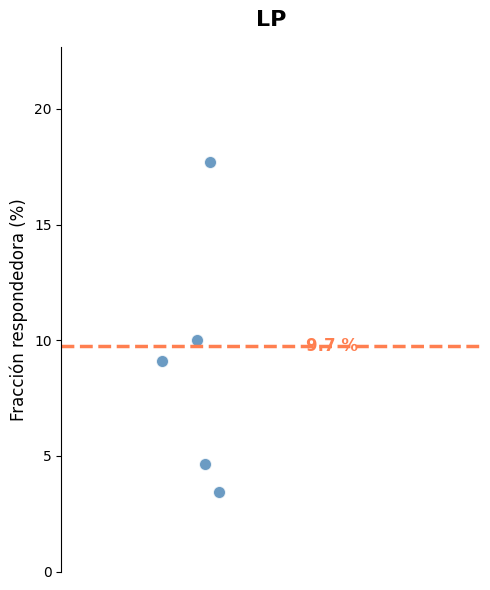

In [7]:
import matplotlib.pyplot as plt
import numpy as np

# Extraer las fracciones calculadas en el paso anterior para la gráfica
fracciones_ratones = []
for raton in ratones_distintos:
    neuronas_raton_idx = np.where(d['u_raton'] == raton)[0]
    num_neuronas_raton = len(neuronas_raton_idx)
    z_scores_raton = z_scores[neuronas_raton_idx]
    num_respondedoras_raton = np.sum(z_scores_raton >= umbral)
    
    if num_neuronas_raton > 0:
        fracciones_ratones.append((num_respondedoras_raton / num_neuronas_raton) * 100)
    else:
        fracciones_ratones.append(0.0)

plt.figure(figsize=(5, 6))

# 1. Un punto por ratón con su fracción respondedora
# Añadimos ruido horizontal (jitter) para que los puntos no se solapen
x_pos = np.random.normal(1, 0.04, len(ratones_distintos))
plt.scatter(x_pos, fracciones_ratones, color='steelblue', s=80, alpha=0.8, edgecolors='w', linewidth=1)

# 2. Una línea horizontal con la fracción del conjunto de las neuronas
plt.axhline(y=fraccion_respondedora * 100, color='coral', linestyle='--', linewidth=2.5)

# 3. El número del conjunto escrito dentro de la figura
plt.text(1.15, fraccion_respondedora * 100, f'{fraccion_respondedora * 100:.1f} %', color='coral', fontsize=12, fontweight='bold', va='center')

# 4. Ejes rotulados
plt.ylabel('Fracción respondedora (%)', fontsize=12)
plt.xticks([]) # Ocultamos el texto del eje X porque todos los puntos son del mismo grupo
plt.xlim(0.8, 1.4)
plt.ylim(0, max(fracciones_ratones) + 5)

# 5. Título con el nombre del área
plt.title('LP', fontsize=16, fontweight='bold', pad=15)

# Limpiar los bordes superior y derecho para que se vea como un artículo científico
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)

plt.tight_layout()
plt.show()

---
## Para cerrar

Anoten su número: **la fracción de neuronas de su área que responden a las rejillas en movimiento**.

Ese número va al póster y es el que comparamos entre las once parejas el viernes 25. Puestos en
orden de área, los once juntos reconstruyen la jerarquía visual del ratón.

Guarden este notebook en su repositorio de GitHub. Es la primera pieza del pipeline del proyecto.